# **Generative Adversarial Networks (GANs): A Comprehensive Guide to Deep Generative Modeling**

**Course:** Deep Learning and Generative AI
**Institution:** IIT Madras  
**Author:** Prof. Ganapathy Krishnamurthi  
**Date:** October 2025

---

## **Learning Objectives**

By the end of this tutorial, students will be able to:

1. **Understand** the theoretical foundations and architecture of Generative Adversarial Networks
2. **Implement** Generator and Discriminator networks for image synthesis
3. **Apply** adversarial training dynamics and minimax optimization
4. **Create** synthetic datasets that closely resemble real data distributions
5. **Evaluate** GAN performance and training stability through loss monitoring
6. **Deploy** trained GANs for generating novel, realistic images

---

## **Prerequisites**

- Strong understanding of PyTorch fundamentals and neural network operations
- Knowledge of feedforward neural networks and backpropagation
- Familiarity with optimization algorithms (SGD, Adam)
- Understanding of probability distributions and sampling
- Experience with image processing and computer vision concepts

## **1. Overview and Theoretical Framework**

### **1.1 Introduction to Generative Adversarial Networks**

**Generative Adversarial Networks (GANs) represent a revolutionary paradigm in deep learning**, introduced by Ian Goodfellow et al. in 2014. GANs enable machines to generate new, synthetic data that closely resembles real data through an adversarial training process.

This tutorial demonstrates the complete implementation of a GAN architecture to generate synthetic Fashion MNIST data, providing insights into adversarial training dynamics and generative modeling techniques.

### **1.2 GAN Architecture and Adversarial Training**

**GANs consist of two neural networks competing in a zero-sum game:**

1. **Generator (G)**: Creates synthetic data from random noise, attempting to fool the discriminator
2. **Discriminator (D)**: Distinguishes between real and generated data, acting as a learned loss function

**Mathematical Framework:**

The GAN training objective can be expressed as a minimax game:

**$min_G max_D V(D, G) = E_{x-p_{data}}(x)[log D(x)] + E_{z-p_z}(z)[log(1 - D(G(z)))]$**

Where:
- **D(x)**: Discriminator's probability that x is real data
- **G(z)**: Generated sample from noise vector z
- **p_data(x)**: Real data distribution
- **p_z(z)**: Prior distribution on noise (typically Gaussian or uniform)

This adversarial process drives both networks to improve: the generator learns to create increasingly realistic samples, while the discriminator becomes better at detection, ultimately reaching a Nash equilibrium where generated samples are indistinguishable from real data.

In [ ]:
# Import essential libraries for deep learning and visualization
import torch
import torch.nn as nn  # Contains all PyTorch building blocks for neural networks
import torchvision
import torchvision.transforms as transforms
from torch.autograd.variable import Variable
import os
import matplotlib.pyplot as plt

# Verify PyTorch installation and version compatibility
# This ensures reproducibility across different environments
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.8.0+cu126
CUDA Available: True
CUDA Version: 12.6
GPU Device: Tesla T4


In [ ]:
# Create directory structure for saving generated samples
# This ensures organized output management during training
sample_dir = 'samples'
if not os.path.exists(sample_dir):
    os.makedirs(sample_dir)
    print(f"Created directory: {sample_dir}")

Created directory: samples


## **2. Hyperparameter Configuration and Experimental Design**

### **2.1 Hyperparameter Selection**

**Hyperparameters critically influence GAN training dynamics and output quality.** The values specified below represent a carefully balanced configuration that promotes stable training and high-quality image generation. Students are encouraged to experiment with different values to develop intuition about each parameter's impact on the training process and final results.

**Note:** GAN training is notoriously sensitive to hyperparameter choices. The parameters below have been tuned for the FashionMNIST dataset and may require adjustment for other datasets or architectures.

In [ ]:
# ============================================================================
# Hyperparameter Configuration for GAN Training
# ============================================================================

# Latent Space Dimension
# Size of the random noise vector used as generator input
# This determines the dimensionality of the latent space from which samples are drawn
# Higher dimensions provide more capacity but may increase training difficulty
latent_size = 64

# Neural Network Architecture
# Size of hidden layers in both generator and discriminator networks
# Controls model capacity and ability to learn complex patterns
# Balance between underfitting (too small) and overfitting (too large)
hidden_size = 256

# Image Specifications
# Total number of pixels in flattened FashionMNIST images (28×28 = 784)
# FashionMNIST images are grayscale, single-channel images of handwritten digits
image_size = 784

# Training Configuration
# Number of complete passes through the entire training dataset
# More epochs allow for better convergence but risk overfitting
# GAN training typically requires fewer epochs than discriminative models
num_epochs = 100

# Batch Processing
# Number of training examples processed in one forward/backward pass
# Larger batches provide more stable gradients but require more memory
# Typical values: 32, 64, 100, 128, 256
batch_size = 100

print("=" * 70)
print("GAN HYPERPARAMETER CONFIGURATION")
print("=" * 70)
print(f"Latent Space Dimension:    {latent_size}")
print(f"Hidden Layer Size:         {hidden_size}")
print(f"Image Size (flattened):    {image_size} ({int(image_size**0.5)}×{int(image_size**0.5)})")
print(f"Training Epochs:           {num_epochs}")
print(f"Batch Size:                {batch_size}")
print("=" * 70)

GAN HYPERPARAMETER CONFIGURATION
Latent Space Dimension:    64
Hidden Layer Size:         256
Image Size (flattened):    784 (28×28)
Training Epochs:           100
Batch Size:                100


### **2.2 Device Configuration and Hardware Acceleration**

**Computational efficiency is critical for deep learning applications.** PyTorch supports automatic device detection and selection, enabling seamless utilization of GPU acceleration when available. This configuration step ensures optimal performance by leveraging available hardware resources.

In [ ]:
# Device configuration for optimal computational performance
# Automatically selects GPU (CUDA) if available, otherwise defaults to CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nCompute Device: {device}")
if device.type == 'cuda':
    print(f"GPU Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")


Compute Device: cuda
GPU Memory Available: 15.83 GB


## **3. Data Preparation and Loading**

In [ ]:
def load_mnist_data(batch_size):
    """
    Load and preprocess FashionMNIST dataset with appropriate transformations.

    This function implements a complete data loading pipeline for GAN training,
    including image normalization and batch preparation.

    Pipeline Steps:
    ---------------
    1. **Transform Definition**:
       - Convert PIL Image to PyTorch Tensor (required for neural network processing)
       - Normalize pixel values to [-1, 1] range for training stability
       - Formula: normalized = (pixel - 0.5) / 0.5
       - This maps [0, 1] → [-1, 1], matching tanh output range

    2. **Dataset Loading**:
       - Download FashionMNIST from torchvision (if not already cached)
       - Apply transformations during loading for memory efficiency
       - Use training set (60,000 images) for GAN training

    3. **DataLoader Creation**:
       - Enable batch processing for efficient GPU utilization
       - Shuffle data each epoch to prevent learning biases
       - Handle automatic batching and parallel data loading

    Parameters:
    -----------
    batch_size : int
        Number of training examples processed in one forward/backward pass.
        Typical values: 32, 64, 100, 128, 256
        Trade-off: Larger batches = more stable gradients but higher memory usage

    Returns:
    --------
    torch.utils.data.DataLoader
        An iterable that yields batches of (images, labels) tuples.
        Each batch contains `batch_size` images and their corresponding labels.

    Notes:
    ------
    - Images are automatically reshaped to (batch_size, 1, 28, 28)
    - Labels are provided but not used in unsupervised GAN training
    - Data is cached in './data/' directory for future runs
    """
    # Define image preprocessing pipeline
    transform = transforms.Compose([
        transforms.ToTensor(),          # Convert PIL Image to Tensor [0, 1]
        transforms.Normalize(           # Normalize to [-1, 1] for tanh compatibility
            mean=[0.5],                 # Mean for single grayscale channel
            std=[0.5]                   # Standard deviation for single channel
        )
    ])

    # Load MNIST training dataset with transformations
    mnist = torchvision.datasets.FashionMNIST(
        root='./data/',                 # Directory for caching downloaded data
        train=True,                     # Use training set (60,000 images)
        transform=transform,            # Apply preprocessing transformations
        download=True                   # Download if not already present
    )

    # Create DataLoader for efficient batch processing
    data_loader = torch.utils.data.DataLoader(
        dataset=mnist,                  # Dataset to load from
        batch_size=batch_size,          # Number of samples per batch
        shuffle=True                    # Randomize order each epoch
    )

    print(f"\nDataset loaded successfully!")
    print(f"Total training images: {len(mnist)}")
    print(f"Batches per epoch: {len(data_loader)}")
    print(f"Image shape: (1, 28, 28)")

    return data_loader

In [ ]:
# Initialize data loader with configured batch size
data_loader = load_mnist_data(batch_size)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.7MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.74MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.6MB/s]


Dataset loaded successfully!
Total training images: 60000
Batches per epoch: 600
Image shape: (1, 28, 28)


## **4. Model Architecture Design**

### **4.1 Generator Network Architecture**

**The Generator (G) is a neural network that learns to map from a random latent space to the data distribution.** It takes a random noise vector as input and produces synthetic images that should be indistinguishable from real images.

**Architectural Design Principles:**
- **Input**: Random noise vector from latent space (Gaussian distribution)
- **Hidden Layers**: Fully connected layers with LeakyReLU activation for non-linearity
- **Output**: Image-space vector with tanh activation to match normalized data range [-1, 1]

**Mathematical Formulation:**
G: z → x', where z ~ N(0, I) and x' ∈ [-1, 1]^(image_size)

The generator progressively transforms random noise into structured image data through learned transformations.

In [ ]:
class Generator(nn.Module):
    """
    Generator Network for GAN Architecture

    The generator learns to transform random noise from a latent space into
    realistic synthetic images through adversarial training.

    Architecture:
    -------------
    Input:  Random noise vector of dimension `latent_size`
    Layer 1: Linear(latent_size → hidden_size) + LeakyReLU(0.2)
    Layer 2: Linear(hidden_size → hidden_size) + LeakyReLU(0.2)
    Output:  Linear(hidden_size → image_size) + Tanh

    Activation Functions:
    ---------------------
    - LeakyReLU: Allows small negative gradients (slope=0.2), preventing dead neurons
      Formula: f(x) = max(0.2x, x)
    - Tanh: Output activation to match normalized image range [-1, 1]
      Formula: f(x) = (e^x - e^-x)/(e^x + e^-x)

    Parameters:
    -----------
    latent_size : int
        Dimension of the input noise vector (latent space)
    hidden_size : int
        Number of neurons in hidden layers
    image_size : int
        Dimension of output image (flattened)
    """

    def __init__(self, latent_size, hidden_size, image_size):
        super(Generator, self).__init__()

        # Define generator architecture as a sequential model
        self.model = nn.Sequential(
            # First transformation: Latent space → Hidden representation
            nn.Linear(latent_size, hidden_size),
            nn.LeakyReLU(0.2),

            # Second transformation: Hidden → Hidden (deeper representation)
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),

            # Final transformation: Hidden → Image space
            nn.Linear(hidden_size, image_size),
            nn.Tanh()  # Output in [-1, 1] matching normalized image range
        )

    def forward(self, z):
        """
        Forward pass: Generate synthetic images from noise vectors.

        Parameters:
        -----------
        z : torch.Tensor
            Random noise vectors of shape (batch_size, latent_size)
            Typically sampled from N(0, I)

        Returns:
        --------
        torch.Tensor
            Generated images of shape (batch_size, image_size)
            Values in range [-1, 1]
        """
        return self.model(z)


# Instantiate generator and move to appropriate device (CPU/GPU)
generator = Generator(latent_size, hidden_size, image_size).to(device)

print("\n" + "=" * 70)
print("GENERATOR ARCHITECTURE")
print("=" * 70)
print(generator)
print("=" * 70)
print(f"Total Parameters: {sum(p.numel() for p in generator.parameters()):,}")
print("=" * 70)


GENERATOR ARCHITECTURE
Generator(
  (model): Sequential(
    (0): Linear(in_features=64, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Tanh()
  )
)
Total Parameters: 283,920


In [ ]:
# Test generator output shape
test_noise = torch.randn(1, latent_size).to(device)
test_output = generator(test_noise)
print(f"\nGenerator Test:")
print(f"Input shape:  {test_noise.shape}")
print(f"Output shape: {test_output.shape}")
print(f"Output range: [{test_output.min().item():.3f}, {test_output.max().item():.3f}]")


Generator Test:
Input shape:  torch.Size([1, 64])
Output shape: torch.Size([1, 784])
Output range: [-0.355, 0.276]


### **4.2 Discriminator Network Architecture**

**The Discriminator (D) is a binary classifier that learns to distinguish between real and generated images.** It acts as a learned loss function, providing feedback to the generator through its classification confidence.

**Architectural Design Principles:**
- **Input**: Image vector (real or generated)
- **Hidden Layers**: Fully connected layers with LeakyReLU activation
- **Output**: Single neuron with sigmoid activation producing probability [0, 1]

**Mathematical Formulation:**
D: x → [0, 1], where D(x) represents the probability that x is real data

**Training Objective:**
- Maximize D(x) for real images (push towards 1)
- Minimize D(G(z)) for generated images (push towards 0)

The discriminator must balance between being too strong (preventing generator learning) and too weak (failing to provide useful gradients).

In [ ]:
class Discriminator(nn.Module):
    """
    Discriminator Network for GAN Architecture

    The discriminator learns to classify images as real or fake, providing
    adversarial feedback to guide generator training.

    Architecture:
    -------------
    Input:  Image vector of dimension `image_size`
    Layer 1: Linear(image_size → hidden_size) + LeakyReLU(0.2)
    Layer 2: Linear(hidden_size → hidden_size) + LeakyReLU(0.2)
    Output:  Linear(hidden_size → 1) + Sigmoid

    Activation Functions:
    ---------------------
    - LeakyReLU: Prevents gradient vanishing, slope=0.2 for negative inputs
    - Sigmoid: Output activation for binary classification [0, 1]
      Formula: σ(x) = 1/(1 + e^-x)
      Output interpretation: Probability that input is real data

    Parameters:
    -----------
    image_size : int
        Dimension of input image (flattened)
    hidden_size : int
        Number of neurons in hidden layers
    """

    def __init__(self, image_size, hidden_size):
        super(Discriminator, self).__init__()

        # Define discriminator architecture as a sequential model
        self.model = nn.Sequential(
            # First transformation: Image space → Hidden representation
            nn.Linear(image_size, hidden_size),
            nn.LeakyReLU(0.2),

            # Second transformation: Hidden → Hidden (deeper representation)
            nn.Linear(hidden_size, hidden_size),
            nn.LeakyReLU(0.2),

            # Final transformation: Hidden → Binary classification
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()  # Output probability in [0, 1]
        )

    def forward(self, x):
        """
        Forward pass: Classify images as real or fake.

        Parameters:
        -----------
        x : torch.Tensor
            Input images of shape (batch_size, image_size)
            Can be real images or generator outputs

        Returns:
        --------
        torch.Tensor
            Classification probabilities of shape (batch_size, 1)
            Values close to 1 indicate "real", close to 0 indicate "fake"
        """
        return self.model(x)


# Instantiate discriminator and move to appropriate device (CPU/GPU)
discriminator = Discriminator(image_size, hidden_size).to(device)

print("\n" + "=" * 70)
print("DISCRIMINATOR ARCHITECTURE")
print("=" * 70)
print(discriminator)
print("=" * 70)
print(f"Total Parameters: {sum(p.numel() for p in discriminator.parameters()):,}")
print("=" * 70)


DISCRIMINATOR ARCHITECTURE
Discriminator(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): LeakyReLU(negative_slope=0.2)
    (4): Linear(in_features=256, out_features=1, bias=True)
    (5): Sigmoid()
  )
)
Total Parameters: 267,009


In [ ]:
# Test discriminator output shape
test_image = torch.randn(1, image_size).to(device)
test_classification = discriminator(test_image)
print(f"\nDiscriminator Test:")
print(f"Input shape:  {test_image.shape}")
print(f"Output shape: {test_classification.shape}")
print(f"Output value: {test_classification.item():.4f} (probability of being real)")


Discriminator Test:
Input shape:  torch.Size([1, 784])
Output shape: torch.Size([1, 1])
Output value: 0.5000 (probability of being real)


## **5. Training Configuration**

### **5.1 Loss Functions and Optimization Strategy**

**Binary Cross-Entropy Loss** is the standard loss function for GAN training, measuring the discrepancy between predicted and true binary classifications.

**Mathematical Definition:**
BCE(y, ŷ) = -[y log(ŷ) + (1-y) log(1-ŷ)]

Where:
- y ∈ {0, 1}: True label (1 for real, 0 for fake)
- ŷ ∈ [0, 1]: Predicted probability from discriminator

### **5.2 Optimizer Initialization**

**Adam (Adaptive Moment Estimation)** optimizer is preferred for GAN training due to its adaptive learning rates and momentum properties, which help navigate the complex, non-convex loss landscapes of adversarial training.

In [ ]:
# Binary Cross-Entropy loss for adversarial training
# Measures the performance of binary classification models
criterion = nn.BCELoss()

# Separate optimizers for generator and discriminator
# Learning rate = 0.0002 (common for GAN training)
# Betas = (0.5, 0.999) momentum parameters for Adam optimizer
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=0.0002)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=0.0002)

print("\nOptimization Configuration:")
print(f"Loss Function: Binary Cross-Entropy")
print(f"Optimizer: Adam")
print(f"Learning Rate: 0.0002")
print(f"Separate optimizers for D and G")


Optimization Configuration:
Loss Function: Binary Cross-Entropy
Optimizer: Adam
Learning Rate: 0.0002
Separate optimizers for D and G


### **5.3 Auxiliary Functions for Training**

**Utility functions to support the training process:**
1. **denorm()**: Reverses normalization for visualization
2. **reset_grad()**: Clears gradients before each optimization step

In [ ]:
def denorm(x):
    """
    Denormalize images for visualization.

    Reverses the normalization transformation applied during data loading,
    converting from [-1, 1] back to [0, 1] range for proper image display.

    Transformation:
    ---------------
    Original normalization: x_norm = (x - 0.5) / 0.5
    Inverse transformation: x = x_norm * 0.5 + 0.5

    This maps [-1, 1] → [0, 1] for matplotlib visualization

    Parameters:
    -----------
    x : torch.Tensor
        Normalized tensor with values in [-1, 1]

    Returns:
    --------
    torch.Tensor
        Denormalized tensor with values in [0, 1]
    """
    out = (x + 1) / 2  # Equivalent to: x * 0.5 + 0.5
    return out.clamp(0, 1)  # Ensure values stay within [0, 1]


def reset_grad():
    """
    Reset gradients for both discriminator and generator optimizers.

    Clears accumulated gradients before each backward pass.
    Essential in PyTorch's dynamic computation graph to prevent
    gradient accumulation from previous iterations.

    Called at the beginning of each training iteration.
    """
    d_optimizer.zero_grad()
    g_optimizer.zero_grad()

## **6. Adversarial Training Loop**

### **6.1 GAN Training Dynamics**

**GAN training involves alternating optimization of two competing objectives:**

**Discriminator Training:**
1. Train on real images (maximize D(x) → 1)
2. Train on fake images (minimize D(G(z)) → 0)
3. Goal: Accurately distinguish real from fake

**Generator Training:**
1. Train to fool discriminator (maximize D(G(z)) → 1)
2. Goal: Generate increasingly realistic images

**Training Algorithm:**
```
For each epoch:
    For each batch:
        1. Train Discriminator:
           - Compute loss on real images
           - Compute loss on generated images
           - Update D parameters
        
        2. Train Generator:
           - Generate new samples
           - Compute loss based on D's classification
           - Update G parameters
```

This adversarial process continues until reaching Nash equilibrium, where the generator produces realistic images and the discriminator cannot reliably distinguish real from fake (D(x) ≈ 0.5).

In [ ]:
# ============================================================================
# GAN TRAINING LOOP
# ============================================================================

# Track training progress
total_step = len(data_loader)
d_losses = []  # Discriminator loss history
g_losses = []  # Generator loss history

print("\n" + "=" * 70)
print("STARTING GAN TRAINING")
print("=" * 70)
print(f"Total Epochs: {num_epochs}")
print(f"Steps per Epoch: {total_step}")
print(f"Total Training Steps: {num_epochs * total_step}")
print("=" * 70 + "\n")

# Main training loop
for epoch in range(num_epochs):
    epoch_d_loss = 0
    epoch_g_loss = 0

    for i, (images, _) in enumerate(data_loader):
        # ====================================================================
        # 1. PREPARE DATA
        # ====================================================================
        # Flatten images from (batch_size, 1, 28, 28) to (batch_size, 784)
        images = images.reshape(batch_size, -1).to(device)

        # Create labels for real and fake images
        real_labels = torch.ones(batch_size, 1).to(device)   # Label = 1 for real
        fake_labels = torch.zeros(batch_size, 1).to(device)  # Label = 0 for fake

        # ====================================================================
        # 2. TRAIN DISCRIMINATOR
        # ====================================================================
        # Objective: Maximize log(D(x)) + log(1 - D(G(z)))
        # Equivalently: Minimize BCE loss on real and fake images

        # Compute loss on real images
        # D should output high probability (close to 1) for real images
        outputs = discriminator(images)
        d_loss_real = criterion(outputs, real_labels)
        real_score = outputs  # Save for monitoring

        # Compute loss on fake images
        # Generate fake images from random noise
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = generator(z)

        # D should output low probability (close to 0) for fake images
        outputs = discriminator(fake_images.detach())  # Detach to avoid backprop through G
        d_loss_fake = criterion(outputs, fake_labels)
        fake_score = outputs  # Save for monitoring

        # Combine losses and update discriminator
        d_loss = d_loss_real + d_loss_fake
        reset_grad()
        d_loss.backward()
        d_optimizer.step()

        # ====================================================================
        # 3. TRAIN GENERATOR
        # ====================================================================
        # Objective: Maximize log(D(G(z)))
        # Equivalently: Minimize BCE loss with real labels
        # (We want D to classify fake images as real)

        # Generate fake images from random noise
        z = torch.randn(batch_size, latent_size).to(device)
        fake_images = generator(z)

        # Try to fool the discriminator
        # G wants D to output high probability (close to 1) for fake images
        outputs = discriminator(fake_images)
        g_loss = criterion(outputs, real_labels)  # Use real_labels to maximize D(G(z))

        # Update generator
        reset_grad()
        g_loss.backward()
        g_optimizer.step()

        # ====================================================================
        # 4. LOGGING AND MONITORING
        # ====================================================================
        # Accumulate losses for epoch averaging
        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()

        # Print progress every 200 steps
        if (i + 1) % 200 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{total_step}], '
                  f'D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}, '
                  f'D(x): {real_score.mean().item():.2f}, D(G(z)): {fake_score.mean().item():.2f}')

    # Record average losses for the epoch
    d_losses.append(epoch_d_loss / total_step)
    g_losses.append(epoch_g_loss / total_step)

    # ========================================================================
    # 5. SAVE GENERATED SAMPLES
    # ========================================================================
    # Save sample images every epoch to visualize training progress
    if (epoch + 1) % 1 == 0:
        fake_images = fake_images.reshape(fake_images.size(0), 1, 28, 28)
        torchvision.utils.save_image(
            denorm(fake_images),
            os.path.join(sample_dir, f'fake_images-{epoch+1}.png')
        )

print("\n" + "=" * 70)
print("TRAINING COMPLETED")
print("=" * 70)
print(f"Final D Loss: {d_losses[-1]:.4f}")
print(f"Final G Loss: {g_losses[-1]:.4f}")
print("=" * 70)


STARTING GAN TRAINING
Total Epochs: 100
Steps per Epoch: 600
Total Training Steps: 60000

Epoch [1/100], Step [200/600], D_loss: 0.0947, G_loss: 3.9471, D(x): 0.96, D(G(z)): 0.05
Epoch [1/100], Step [400/600], D_loss: 0.2134, G_loss: 4.8914, D(x): 0.96, D(G(z)): 0.07
Epoch [1/100], Step [600/600], D_loss: 0.1337, G_loss: 3.1818, D(x): 0.95, D(G(z)): 0.08
Epoch [2/100], Step [200/600], D_loss: 0.4069, G_loss: 3.1944, D(x): 0.85, D(G(z)): 0.13
Epoch [2/100], Step [400/600], D_loss: 0.0660, G_loss: 3.7068, D(x): 0.98, D(G(z)): 0.04
Epoch [2/100], Step [600/600], D_loss: 0.2118, G_loss: 3.8226, D(x): 0.94, D(G(z)): 0.09
Epoch [3/100], Step [200/600], D_loss: 0.1789, G_loss: 4.9668, D(x): 0.97, D(G(z)): 0.11
Epoch [3/100], Step [400/600], D_loss: 0.5723, G_loss: 3.1627, D(x): 0.84, D(G(z)): 0.12
Epoch [3/100], Step [600/600], D_loss: 0.3526, G_loss: 4.0870, D(x): 0.88, D(G(z)): 0.08
Epoch [4/100], Step [200/600], D_loss: 0.5125, G_loss: 3.0674, D(x): 0.85, D(G(z)): 0.17
Epoch [4/100], Step

In [ ]:
# Display training summary
print(f"\nTraining Statistics:")
print(f"Epochs completed: {len(d_losses)}")
print(f"Average D Loss: {sum(d_losses)/len(d_losses):.4f}")
print(f"Average G Loss: {sum(g_losses)/len(g_losses):.4f}")


Training Statistics:
Epochs completed: 100
Average D Loss: 0.7651
Average G Loss: 2.0232


## **7. Model Evaluation and Analysis**

### **7.1 Training Loss Visualization**

**Monitoring loss curves is crucial for assessing GAN training dynamics and identifying potential issues:**

- **Stable Training**: Both losses should decrease and stabilize over time
- **Mode Collapse**: G loss decreases while D loss increases dramatically
- **Discriminator Dominance**: D loss approaches zero, G loss increases
- **Generator Dominance**: G loss approaches zero, D loss increases

**Ideal Scenario:** Balanced competition where both losses oscillate around stable values, indicating Nash equilibrium.

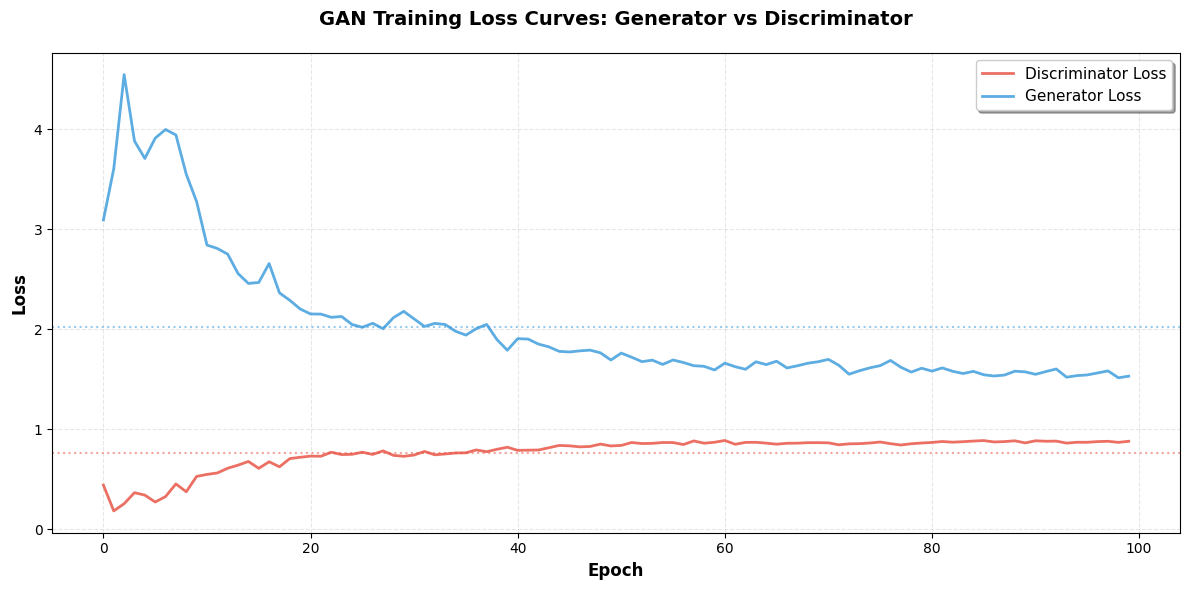


LOSS ANALYSIS
Final D Loss:     0.8781
Final G Loss:     1.5290
Average D Loss:   0.7651
Average G Loss:   2.0232
Loss Ratio (G/D): 1.7413


In [ ]:
# ============================================================================
# VISUALIZE TRAINING LOSS CURVES
# ============================================================================

# Create figure with improved aesthetics
plt.figure(figsize=(12, 6))

# Plot discriminator loss
plt.plot(d_losses, label='Discriminator Loss',
         linewidth=2, color='#e74c3c', alpha=0.8)

# Plot generator loss
plt.plot(g_losses, label='Generator Loss',
         linewidth=2, color='#3498db', alpha=0.8)

# Enhance plot appearance
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss', fontsize=12, fontweight='bold')
plt.title('GAN Training Loss Curves: Generator vs Discriminator',
          fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='upper right', fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')

# Add informative annotations
plt.axhline(y=sum(d_losses)/len(d_losses), color='#e74c3c',
            linestyle=':', alpha=0.5, label=f'Avg D Loss: {sum(d_losses)/len(d_losses):.3f}')
plt.axhline(y=sum(g_losses)/len(g_losses), color='#3498db',
            linestyle=':', alpha=0.5, label=f'Avg G Loss: {sum(g_losses)/len(g_losses):.3f}')

plt.tight_layout()
plt.show()

# Print loss analysis
print("\n" + "=" * 70)
print("LOSS ANALYSIS")
print("=" * 70)
print(f"Final D Loss:     {d_losses[-1]:.4f}")
print(f"Final G Loss:     {g_losses[-1]:.4f}")
print(f"Average D Loss:   {sum(d_losses)/len(d_losses):.4f}")
print(f"Average G Loss:   {sum(g_losses)/len(g_losses):.4f}")
print(f"Loss Ratio (G/D): {g_losses[-1]/d_losses[-1]:.4f}")
print("=" * 70)

In [ ]:
# ============================================================================
# SAVE TRAINED MODEL WEIGHTS
# ============================================================================

# Save the generator and discriminator model checkpoints
# This allows loading the trained models later for generating images
torch.save(generator.state_dict(), 'generator.pth')
torch.save(discriminator.state_dict(), 'discriminator.pth')

print("\n" + "=" * 70)
print("MODEL WEIGHTS SAVED")
print("=" * 70)
print("Generator weights saved to: generator.pth")
print("Discriminator weights saved to: discriminator.pth")
print("=" * 70)


MODEL WEIGHTS SAVED
Generator weights saved to: generator.pth
Discriminator weights saved to: discriminator.pth


### **7.2 Generated Image Quality Assessment**

**Visual inspection of generated images provides qualitative evaluation of GAN performance:**

- **Early Training**: Noisy, unstructured patterns
- **Mid Training**: Recognizable dress shapes emerge
- **Late Training**: Clear, realistic images

**Quality Metrics to Consider:**
1. **Visual Fidelity**: Do images look realistic?
2. **Diversity**: Are multiple dress styles represented?
3. **Mode Coverage**: Are all 10 types of clothing is generated?
4. **Artifacts**: Presence of visual distortions or noise?


REAL VS GENERATED IMAGE COMPARISON


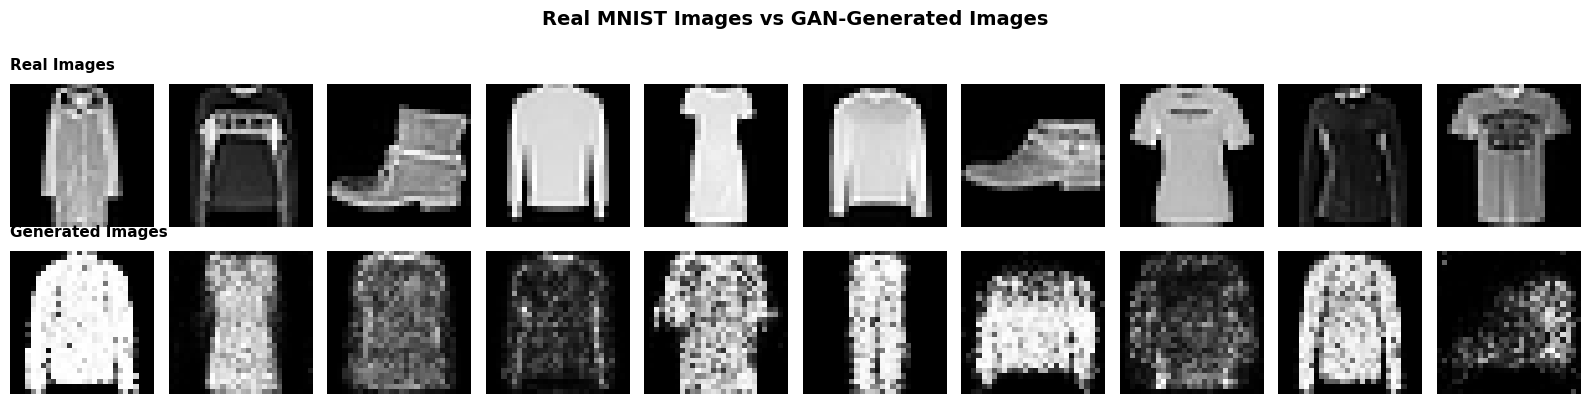


Visual Comparison Complete
Top Row:    Real MNIST training images
Bottom Row: GAN-generated synthetic images


In [ ]:
# ============================================================================
# VISUALIZE REAL VS GENERATED IMAGES
# ============================================================================

# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 10, figsize=(16, 4))

# Display real images from training data
print("\n" + "=" * 70)
print("REAL VS GENERATED IMAGE COMPARISON")
print("=" * 70)

# Get a batch of real images
real_batch = next(iter(data_loader))
real_images = real_batch[0][:10]

# Display real images
for i in range(10):
    axes[0, i].imshow(real_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Real Images', fontweight='bold',
                              loc='left', fontsize=11, pad=10)

# Generate and display fake images
generator.eval()  # Set to evaluation mode
with torch.no_grad():
    z = torch.randn(10, latent_size).to(device)
    fake_images = generator(z)
    fake_images = fake_images.view(-1, 1, 28, 28)
    fake_images = denorm(fake_images).cpu()

for i in range(10):
    axes[1, i].imshow(fake_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Generated Images', fontweight='bold',
                              loc='left', fontsize=11, pad=10)

plt.suptitle('Real MNIST Images vs GAN-Generated Images',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

generator.train()  # Return to training mode

print("\nVisual Comparison Complete")
print("Top Row:    Real MNIST training images")
print("Bottom Row: GAN-generated synthetic images")
print("=" * 70)